# Fine-Tuning Mullen et al. (2023) EfficientNetB7-UNet — Sequential Experiments

Fine-tunes the Mullen et al. (2023) slope model on local NC PlanetScope imagery,
running three experiments sequentially to isolate the contribution of domain adaptation
and augmentation strategy.

| # | Name | Description |
|---|------|-------------|
| 1 | `mullen_unaltered` | Mullen weights, 5-band input (B/G/R/NIR/slope), zero fine-tuning — baseline |
| 2 | `mullen_finetune_standard` | Mullen weights → 11-band, gradual unfreeze, standard augmentation |
| 3 | `mullen_finetune_aggressive` | Mullen weights → 11-band, gradual unfreeze, aggressive augmentation |

## Architecture
- **Encoder:** EfficientNetB7 (Mullen's trained weights from `single_class_slope_best_model.h5`)
- **Decoder:** segmentation-models-pytorch UNet decoder
- **Output:** 2-class softmax, `ignore_index=255` for no-data

## Band reordering
Stored order `[coastal_blue=0, blue=1, green=2, red=3, rededge=4, nir=5, ndvi=6, ndwi=7, ndre=8, nisi=9]`
is reordered to `[blue=0, green=1, red=2, nir=3, ndvi=4, ndwi=5, ndre=6, nisi=7, coastal_blue=8, rededge=9]`
so Mullen's B/G/R/NIR weights transfer directly to positions 0–3.

## Fine-tuning strategy (Option B — gradual unfreeze)
- **Phase 1 (epochs 1–20):** Encoder frozen, decoder trains at LR=1e-4
- **Phase 2 (epochs 21–50):** Encoder LR=1e-5, decoder LR=1e-4

## Normalisation
Mullen convention: `(SR_integer / 10000.0) * 255`, no-data→0.5, then EfficientNetB7 ImageNet preprocessing.
Slope: z-score normalised using training scene statistics.

---
## 0.1 Install Dependencies

In [2]:
import subprocess, sys
pkgs = ["rasterio", "rioxarray", "geopandas", "albumentations",
        "torchinfo", "torchmetrics>=1.3", "segmentation-models-pytorch", "h5py"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("Installation complete")

Installation complete


---
## 0.2 Mount Google Drive

In [3]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)
print("Drive mounted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted


---
## 0.3 Configuration

In [4]:
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
DRIVE_ROOT       = Path("/content/drive/MyDrive/Research/EO-Methane/paper2")
MULLEN_H5        = DRIVE_ROOT / "mullen23_models" / "single_class_slope_best_model.h5"

LOCAL_IMAGE_DIR  = DRIVE_ROOT / "data" / "local_nc" / "20240716_151643_20_24c8" / "PS"
LOCAL_MASK_DIR   = DRIVE_ROOT / "data" / "local_nc" / "20240716_151643_20_24c8" / "labels"

EXPERIMENTS_DIR  = DRIVE_ROOT / "experiments_mullen"
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)

SLOPE_TILE_DIR = DRIVE_ROOT / "data" / "DEM" / "slope_tiles"
SLOPE_TILE_SHP = DRIVE_ROOT / "data" / "Shapefiles" / "coastal_grid_epsg32119" / "coastal_grid_epsg32119.shp"
LOCAL_SLOPE_DIR  = DRIVE_ROOT / "data" / "local_nc" / "slope"
LOCAL_SLOPE_DIR.mkdir(parents=True, exist_ok=True)

# ── Band config ───────────────────────────────────────────────────────────────
# Reorder from stored → model input order so Mullen's B/G/R/NIR → positions 0-3
# Stored: [coastal_blue=0, blue=1, green=2, red=3, rededge=4,
#           nir=5, ndvi=6, ndwi=7, ndre=8, nisi=9]
# Model:  [blue=0, green=1, red=2, nir=3, ndvi=4, ndwi=5,
#           ndre=6, nisi=7, coastal_blue=8, rededge=9, slope=10]
BAND_REORDER     = [1, 2, 3, 5, 6, 7, 8, 9, 0, 4]   # 10 spectral bands
N_BANDS_MULLEN   = 5    # Mullen's original input (B/G/R/NIR/slope)
N_BANDS_FINETUNE = 11   # our extended input

# Mullen stem conv: position 0=B,1=G,2=R,3=NIR,4=slope
# After reorder, our positions 0-3 = B/G/R/NIR → direct transfer
SPECTRAL_SIMILARITY = {
    0:  0,   # blue          → blue   (direct)
    1:  1,   # green         → green  (direct)
    2:  2,   # red           → red    (direct)
    3:  3,   # nir           → nir    (direct)
    4:  3,   # ndvi          → nir
    5:  1,   # ndwi          → green
    6:  3,   # ndre          → nir
    7:  1,   # nisi          → green
    8:  0,   # coastal_blue  → blue
    9:  2,   # rededge       → red
    10: 4,   # slope         → slope  (direct)
}

# ── Training ──────────────────────────────────────────────────────────────────
CHIP_SIZE      = 256
BATCH_SIZE     = 8
PHASE1_EPOCHS  = 10   # was 20 -> need more local data to inc number
PHASE2_EPOCHS  = 15   # was 30
TOTAL_EPOCHS   = PHASE1_EPOCHS + PHASE2_EPOCHS
LR_DECODER     = 1e-4
LR_ENCODER     = 1e-5
EARLY_STOP_PATIENCE = 5
N_VAL_SCENES   = 2
N_TEST_SCENES  = 1
RANDOM_SEED    = 42

print(f"Experiments dir: {EXPERIMENTS_DIR}")
print(f"Fine-tune epochs: {TOTAL_EPOCHS} ({PHASE1_EPOCHS} frozen + {PHASE2_EPOCHS} unfrozen)")

Experiments dir: /content/drive/MyDrive/Research/EO-Methane/paper2/experiments_mullen
Fine-tune epochs: 25 (10 frozen + 15 unfrozen)


---
## 1. Imports

In [5]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import random
import warnings
warnings.filterwarnings("ignore")

import h5py
import rasterio
from rasterio.windows import Window
from rasterio.merge import merge
from rasterio.warp import reproject, Resampling

import geopandas as gpd
from shapely.geometry import box

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from torchinfo import summary
import torchmetrics

import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.notebook import tqdm

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU — EfficientNetB7 will be very slow on CPU")
print(f"PyTorch: {torch.__version__}  SMP: {smp.__version__}")

GPU: Tesla T4
VRAM: 15.6 GB
PyTorch: 2.11.0+cu128  SMP: 0.5.0


---
## 2. Shared Setup
Runs once. Scene split, slope statistics, and chip index are fixed across all experiments.

In [6]:
# ── Slope tile matching and alignment ─────────────────────────────────────────
# Identifies overlapping slope tiles, mosaics if needed, then reprojects
# to exactly match the PS scene pixel grid (same CRS, transform, extent).
# Since slope is already at 3m, this is pixel alignment only — no resampling
# quality loss. Safe to rerun — skips scenes where output already exists.

def find_overlapping_tiles(ps_path: Path, tile_gdf: gpd.GeoDataFrame,
                            tile_path_col: str = "path") -> list:
    with rasterio.open(ps_path) as src:
        ps_box = gpd.GeoDataFrame(
            geometry=[box(*src.bounds)], crs=src.crs
        ).to_crs(tile_gdf.crs)
    overlaps = tile_gdf[tile_gdf.intersects(ps_box.geometry.iloc[0])]
    if len(overlaps) == 0:
        raise ValueError(f"No slope tiles overlap {ps_path.name}.")
    return overlaps[tile_path_col].tolist()


def align_slope_to_ps(slope_paths: list, reference_path: Path,
                       output_path: Path) -> None:
    """
    Mosaic overlapping slope tiles (if >1) then align to the PS scene
    pixel grid. Since slope is already 3m, this only corrects CRS and
    pixel origin — no resolution resampling occurs.
    """
    # Open and mosaic tiles if needed
    src_files = [rasterio.open(p) for p in slope_paths]
    if len(src_files) > 1:
        mosaic, mosaic_transform = merge(src_files)
        mosaic_crs = src_files[0].crs
        mosaic_nodata = src_files[0].nodata
    else:
        src     = src_files[0]
        mosaic  = src.read()
        mosaic_transform = src.transform
        mosaic_crs       = src.crs
        mosaic_nodata    = src.nodata

    # Read reference PS scene grid
    with rasterio.open(reference_path) as ref:
        dst_crs       = ref.crs
        dst_transform = ref.transform
        dst_width     = ref.width
        dst_height    = ref.height
        dst_profile   = ref.profile.copy()

    # Align to PS grid
    dst_array = np.full((1, dst_height, dst_width), -9999, dtype=np.float32)
    reproject(
        source        = mosaic[0].astype(np.float32),
        destination   = dst_array[0],
        src_transform = mosaic_transform,
        src_crs       = mosaic_crs,
        dst_transform = dst_transform,
        dst_crs       = dst_crs,
        resampling    = Resampling.bilinear,   # handles sub-pixel origin shift
        src_nodata    = -9999,
        dst_nodata    = -9999,
    )

    # Write output matching PS profile exactly
    dst_profile.update(count=1, dtype="float32", nodata=-9999, compress="lzw")
    with rasterio.open(output_path, "w", **dst_profile) as dst:
        dst.write(dst_array)

    for f in src_files: f.close()


def prepare_slope_tiles(img_lst: list, tile_gdf: gpd.GeoDataFrame,
                         tile_path_col: str = "path",
                         overwrite: bool = False) -> None:
    print(f"Aligning slope tiles for {len(img_lst)} PS images...")
    for img_path in img_lst:
        out_path = LOCAL_SLOPE_DIR / img_path.name

        if out_path.exists() and not overwrite:
            print(f"  {img_path.name}: already exists, skipping")
            continue

        try:
            tile_paths = find_overlapping_tiles(img_path, tile_gdf, tile_path_col)
            print(f"  {img_path.name}: {len(tile_paths)} tile(s)")
            align_slope_to_ps(tile_paths, img_path, out_path)

            # Validate alignment
            with rasterio.open(out_path) as s, rasterio.open(img_path) as r:
                assert s.crs    == r.crs,    "CRS mismatch"
                assert s.width  == r.width,  "Width mismatch"
                assert s.height == r.height, "Height mismatch"
                assert np.isclose(s.transform.a, r.transform.a, rtol=1e-4), \
                    "Resolution mismatch"
                assert np.isclose(s.transform.c, r.transform.c, rtol=1e-4) and \
                       np.isclose(s.transform.f, r.transform.f, rtol=1e-4), \
                    "Origin mismatch"
            print(f"    ✓ aligned: {out_path.name}")

        except Exception as e:
            print(f"  ERROR for {img_path.name}: {e}")

    print("Done.")


# ── Run ───────────────────────────────────────────────────────────────────────
tile_gdf = gpd.read_file(SLOPE_TILE_SHP)
print(f"Tile index: {len(tile_gdf)} tiles, CRS={tile_gdf.crs}")
print(f"Columns: {tile_gdf.columns.tolist()}")

# Add this after loading the shapefile:
# tile_gdf["id"] = tile_gdf["id"].apply(lambda f: str(SLOPE_TILE_DIR / f))
# If the id already includes the .tif extension, this is sufficient.
# If not, add it:
tile_gdf["id"] = tile_gdf["id"].apply(lambda f: str(SLOPE_TILE_DIR / f"slope_{int(f)}.tif"))

# Update to match the column in your shapefile that holds the tile path or filename
TILE_PATH_COL = "id"
# If the column is a filename only, construct full paths:
# tile_gdf["path"] = tile_gdf["filename"].apply(lambda f: str(SLOPE_TILE_DIR / f))

Tile index: 325 tiles, CRS=EPSG:32119
Columns: ['id', 'left', 'top', 'right', 'bottom', 'geometry']


In [16]:
tile_gdf["id"][0]

'/content/drive/MyDrive/Research/EO-Methane/paper2/data/DEM/slope_tiles/slope_592.tif'

In [7]:
# ── Band reordering ───────────────────────────────────────────────────────────
def reorder_bands(chip: np.ndarray) -> np.ndarray:
    """
    Reorder 10-band chip from stored order to model input order.
    Stored: [coastal_blue, blue, green, red, rededge, nir, ndvi, ndwi, ndre, nisi]
    Model:  [blue, green, red, nir, ndvi, ndwi, ndre, nisi, coastal_blue, rededge]
    This places Mullen's B/G/R/NIR at positions 0-3 for direct weight transfer.
    """
    return chip[BAND_REORDER, :, :]


def verify_band_reorder(scene_path: Path):
    """Verify reordering is correct by checking band means match."""
    stored_names  = ["coastal_blue","blue","green","red","rededge",
                     "nir","ndvi","ndwi","ndre","nisi"]
    model_names   = ["blue","green","red","nir","ndvi","ndwi",
                     "ndre","nisi","coastal_blue","rededge"]
    with rasterio.open(scene_path) as src:
        chip = src.read(window=Window(0, 0, 256, 256)).astype(np.float32)
    reordered = reorder_bands(chip)
    print(f"Band reorder verification ({scene_path.name}):")
    print(f"  {'Model pos':>9}  {'Model name':>14}  {'Stored idx':>10}  {'Match':>5}")
    all_ok = True
    for mi, si in enumerate(BAND_REORDER):
        match = np.isclose(chip[si].mean(), reordered[mi].mean())
        flag  = "✓" if match else "✗"
        if not match: all_ok = False
        print(f"  {mi:>9}  {model_names[mi]:>14}  "
              f"{si:>10} ({stored_names[si]:>12})  {flag:>5}")
    print(f"  {'All correct' if all_ok else 'ERRORS FOUND'}")


# ── Normalisation ─────────────────────────────────────────────────────────────
EFFICIENTNET_MEAN = 0.449    # ImageNet RGB mean averaged across channels
EFFICIENTNET_STD  = 0.226    # ImageNet RGB std averaged across channels

def preprocess_spectral(chip: np.ndarray) -> np.ndarray:
    """
    Mullen normalisation for spectral/index bands.
    chip: (10, H, W) float32, already reordered, SR integers (*10000)
    Returns: (10, H, W) float32 EfficientNet-normalised
    """
    chip = chip.astype(np.float32)
    chip = (chip / 10000.0) * 255.0   # SR integers → 0-255 display scale
    chip[chip == 0] = 0.5             # no-data replacement (Mullen convention)
    chip = chip / 255.0               # → 0-1
    chip = (chip - EFFICIENTNET_MEAN) / EFFICIENTNET_STD
    return chip


def preprocess_slope(slope: np.ndarray, mean: float, std: float) -> np.ndarray:
    slope = slope.astype(np.float32)
    slope[slope == -9999] = np.nan
    slope = np.nan_to_num(slope, nan=0.0)
    return (slope - mean) / (std + 1e-6)


# ── Chip offsets ──────────────────────────────────────────────────────────────
def get_chip_offsets(total, chip_size):
    offsets = list(range(0, total - chip_size + 1, chip_size))
    if not offsets or offsets[-1] + chip_size < total:
        offsets.append(max(0, total - chip_size))
    return offsets


# ── Scene discovery ───────────────────────────────────────────────────────────
def list_local_scenes(image_dir, slope_dir, mask_dir):
    scenes = []
    for img_path in sorted(image_dir.glob("*.tif")):
        slope_path = slope_dir / img_path.name
        mask_path  = mask_dir  / img_path.name.replace('tile', 'label')
        if not slope_path.exists():
            print(f"  Warning: no slope for {img_path.name}"); continue
        if not mask_path.exists():
            print(f"  Warning: no mask for {img_path.name}");  continue
        scenes.append((img_path, slope_path, mask_path))
    print(f"Found {len(scenes)} complete scene triples")
    return scenes


print("Shared utilities defined.")

Shared utilities defined.


In [8]:
# ── Load scenes ───────────────────────────────────────────────────────────────

prepare_slope_tiles(sorted(LOCAL_IMAGE_DIR.glob("*.tif")), tile_gdf, tile_path_col=TILE_PATH_COL)

scenes = list_local_scenes(LOCAL_IMAGE_DIR, LOCAL_SLOPE_DIR, LOCAL_MASK_DIR)

# Verify band reorder on first scene
verify_band_reorder(scenes[0][0])

# ── Scene-level split (fixed for all experiments) ─────────────────────────────
assert len(scenes) >= N_VAL_SCENES + N_TEST_SCENES + 1
order = list(range(len(scenes)))
random.shuffle(order)
test_scene_idx  = set(order[:N_TEST_SCENES])
val_scene_idx   = set(order[N_TEST_SCENES:N_TEST_SCENES + N_VAL_SCENES])
train_scene_idx = set(order[N_TEST_SCENES + N_VAL_SCENES:])

print(f"\nScene split — train: {len(train_scene_idx)}  "
      f"val: {len(val_scene_idx)}  test: {len(test_scene_idx)}")
print("Test scenes:", [scenes[i][0].name for i in sorted(test_scene_idx)])

# ── Slope statistics from training scenes ─────────────────────────────────────
print("\nComputing slope statistics from training scenes...")
slope_vals = []
for i in train_scene_idx:
    with rasterio.open(scenes[i][1]) as src:
        data = src.read(1, masked=False).astype(np.float32)
    valid = data[(data != -9999) & (data > 0)]
    slope_vals.append(valid)
slope_all  = np.concatenate(slope_vals)
SLOPE_MEAN = float(np.mean(slope_all))
SLOPE_STD  = float(np.std(slope_all))
print(f"  Slope mean: {SLOPE_MEAN:.3f}°  std: {SLOPE_STD:.3f}°")
np.save(EXPERIMENTS_DIR / "slope_stats.npy", {"mean": SLOPE_MEAN, "std": SLOPE_STD})

# ── Chip indices ──────────────────────────────────────────────────────────────
all_chips = []
for i, (img_path, _, _) in enumerate(scenes):
    with rasterio.open(img_path) as src:
        H, W = src.height, src.width
    for r in get_chip_offsets(H, CHIP_SIZE):
        for c in get_chip_offsets(W, CHIP_SIZE):
            all_chips.append((i, r, c))

train_chips = [c for c in all_chips if c[0] in train_scene_idx]
val_chips   = [c for c in all_chips if c[0] in val_scene_idx]
test_chips  = [c for c in all_chips if c[0] in test_scene_idx]
print(f"Chips — train: {len(train_chips)}  val: {len(val_chips)}  test: {len(test_chips)}")

Aligning slope tiles for 9 PS images...
  tile_10240_6144.tif: already exists, skipping
  tile_10240_7168.tif: already exists, skipping
  tile_11264_6144.tif: already exists, skipping
  tile_11264_7168.tif: already exists, skipping
  tile_11264_8192.tif: already exists, skipping
  tile_8192_6144.tif: already exists, skipping
  tile_8192_7168.tif: already exists, skipping
  tile_9216_6144.tif: already exists, skipping
  tile_9216_7168.tif: already exists, skipping
Done.
Found 9 complete scene triples
Band reorder verification (tile_10240_6144.tif):
  Model pos      Model name  Stored idx  Match
          0            blue           1 (        blue)      ✓
          1           green           2 (       green)      ✓
          2             red           3 (         red)      ✓
          3             nir           5 (         nir)      ✓
          4            ndvi           6 (        ndvi)      ✓
          5            ndwi           7 (        ndwi)      ✓
          6            ndre

---
## 3. Augmentation Pipelines

**Standard:** flip, rotate, shift/scale/rotate, mild brightness/contrast.

**Aggressive:** all of the above plus elastic deformation, grid distortion, coarse dropout,
Gaussian blur, and stronger brightness/contrast. Particularly useful for small datasets
where the model needs to generalise from few examples.

In [9]:
val_transform = A.Compose([ToTensorV2()])

standard_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
    ToTensorV2()
])

aggressive_transform = A.Compose([
    # Geometric — same as standard
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
    # Elastic / grid deformation — simulates natural boundary variation
    # Particularly useful for irregular water body shapes
    A.ElasticTransform(
        alpha=120, sigma=6, p=0.3
    ),
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),
    # Radiometric — stronger range, simulates atmospheric/illumination variation
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussNoise(var_limit=(0.001, 0.01), p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    # Coarse dropout — forces model to learn from partial observations,
    # simulating cloud shadows or sensor artefacts
    A.CoarseDropout(
        max_holes=8, max_height=32, max_width=32,
        min_holes=2, min_height=8,  min_width=8,
        fill_value=0, mask_fill_value=255,   # filled pixels ignored in loss
        p=0.3
    ),
    ToTensorV2()
])

TRANSFORMS = {
    "none":       val_transform,        # for Exp 1 unaltered (no augmentation)
    "standard":   standard_transform,
    "aggressive": aggressive_transform,
}
print("Augmentation pipelines defined.")

Augmentation pipelines defined.


---
## 4. Dataset, Model, Loss & Training Utilities

In [10]:
class LocalWaterDataset(Dataset):
    """
    n_bands=5  → Mullen 5-band input [B, G, R, NIR, slope] (Experiment 1)
    n_bands=11 → Full 11-band input  (Experiments 2 & 3)
    """
    def __init__(self, scenes, chip_index, chip_size=256,
                 slope_mean=0.0, slope_std=1.0,
                 n_bands=11, transform=None):
        self.scenes     = scenes
        self.chip_index = chip_index
        self.chip_size  = chip_size
        self.slope_mean = slope_mean
        self.slope_std  = slope_std
        self.n_bands    = n_bands
        self.transform  = transform

    def __len__(self): return len(self.chip_index)

    def _load_chip(self, path, row, col, bands=None):
        window = Window(col, row, self.chip_size, self.chip_size)
        with rasterio.open(path) as src:
            return src.read(
                [b+1 for b in bands] if bands else None,
                window=window, out_dtype=np.float32
            )

    def __getitem__(self, idx):
        scene_i, row, col            = self.chip_index[idx]
        img_path, slope_path, mask_p = self.scenes[scene_i]

        if self.n_bands == 5:
            # Experiment 1: Mullen 5-band [B, G, R, NIR, slope]
            # Read bands matching Mullen's order from stored indices
            # stored: coastal_blue=0,blue=1,green=2,red=3,rededge=4,nir=5
            mullen_spec = self._load_chip(img_path, row, col, bands=[1,2,3,5])  # B,G,R,NIR
            mullen_spec = preprocess_spectral(mullen_spec)
            slp         = self._load_chip(slope_path, row, col)
            slp         = preprocess_slope(slp, self.slope_mean, self.slope_std)
            image       = np.concatenate([mullen_spec, slp], axis=0)  # (5, H, W)
        else:
            # Experiments 2 & 3: full 11-band reordered stack
            spec  = self._load_chip(img_path, row, col)               # (10, H, W) stored
            spec  = reorder_bands(spec)                               # (10, H, W) model order
            spec  = preprocess_spectral(spec)
            slp   = self._load_chip(slope_path, row, col)
            slp   = preprocess_slope(slp, self.slope_mean, self.slope_std)
            image = np.concatenate([spec, slp], axis=0)              # (11, H, W)

        image = np.nan_to_num(image, nan=0.0, posinf=3.0, neginf=-3.0)

        mask = self._load_chip(mask_p, row, col)[0].astype(np.uint8)  # (H, W)

        if self.transform:
            aug   = self.transform(image=image.transpose(1,2,0),
                                   mask=mask.astype(np.float32))
            image = aug["image"]
            mask  = aug["mask"].long()
        else:
            image = torch.from_numpy(image)
            mask  = torch.from_numpy(mask.astype(np.int64))
        return image, mask


# ── Model builder ─────────────────────────────────────────────────────────────
def build_model(n_bands: int) -> smp.Unet:
    return smp.Unet(
        encoder_name="efficientnet-b7",
        encoder_weights=None,
        in_channels=n_bands,
        classes=2,
        activation=None,
    )


# ── Weight transfer ───────────────────────────────────────────────────────────
def transfer_encoder_weights(model: smp.Unet, h5_path: Path,
                              n_new_bands: int,
                              spectral_map: dict = SPECTRAL_SIMILARITY):
    """
    Transfer EfficientNetB7 encoder weights from Mullen's Keras .h5.
    Handles stem conv channel extension and Keras→PyTorch format conversion.
    For n_new_bands=5 (Exp 1), only the stem conv channel count changes
    (5→5, so it's a direct copy with no extension needed).
    """
    with h5py.File(h5_path, "r") as f:
        keras_weights = {}
        f["model_weights"].visititems(
            lambda name, obj: keras_weights.update(
                {name: np.array(obj)}) if isinstance(obj, h5py.Dataset) else None
        )

    transferred = 0

    # ── Stem conv: extend/copy to n_new_bands ────────────────────────────────
    stem_k = next((v for k,v in keras_weights.items() if "stem_conv" in k
                   and "kernel" in k), None)
    if stem_k is not None:
        n_mullen = stem_k.shape[2]   # 5 for slope model
        # keras (H,W,in,out) → pytorch (out,in,H,W)
        new_stem = np.zeros((64, n_new_bands, 3, 3), dtype=np.float32)
        for new_i in range(n_new_bands):
            src_i = spectral_map.get(new_i, 0)
            src_i = min(src_i, n_mullen - 1)   # guard against out-of-range
            new_stem[:, new_i, :, :] = stem_k[:, :, src_i, :].transpose(2, 0, 1)
        for name, param in model.encoder.named_parameters():
            if "stem" in name and param.dim() == 4 and param.shape[0] == 64:
                with torch.no_grad():
                    param.copy_(torch.from_numpy(new_stem))
                transferred += 1
                print(f"  Stem conv: keras {stem_k.shape} → pytorch {tuple(new_stem.shape)}")
                break

    # ── Stem BN ───────────────────────────────────────────────────────────────
    bn_map = {
        "stem_bn/stem_bn/gamma:0":           ".weight",
        "stem_bn/stem_bn/beta:0":            ".bias",
        "stem_bn/stem_bn/moving_mean:0":     ".running_mean",
        "stem_bn/stem_bn/moving_variance:0": ".running_var",
    }
    enc_bufs = dict(model.encoder.named_buffers())
    enc_pars = dict(model.encoder.named_parameters())
    for keras_key, pt_suffix in bn_map.items():
        arr = keras_weights.get(keras_key)
        if arr is None: continue
        candidates = {**enc_pars, **enc_bufs}
        for k, v in candidates.items():
            if "stem" in k and k.endswith(pt_suffix[1:]) and v.shape == torch.Size([64]):
                with torch.no_grad(): v.copy_(torch.from_numpy(arr))
                transferred += 1; break

    print(f"  Directly transferred: {transferred} tensors")
    print(f"  Block weights: transfer by shape-matching in full fine-tune run.")
    print(f"  Run verify_transfer() to confirm encoder is non-trivial.")
    return model


def verify_transfer(model, n_bands):
    model.eval()
    with torch.no_grad():
        dummy = torch.randn(1, n_bands, 256, 256).to(DEVICE)
        feats = model.encoder(dummy)
    print("Encoder feature map stats:")
    for i, f in enumerate(feats):
        if f is not None:
            print(f"  Level {i}: {tuple(f.shape)}  "
                  f"mean={f.mean().item():.4f}  std={f.std().item():.4f}")


# ── Loss ──────────────────────────────────────────────────────────────────────
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0, ignore_index=255):
        super().__init__()
        self.smooth = smooth; self.ignore_index = ignore_index
    def forward(self, logits, targets):
        valid     = targets != self.ignore_index
        probs     = torch.softmax(logits, dim=1)[:,1][valid]
        targets_f = targets[valid].float()
        intersect = (probs * targets_f).sum()
        return 1. - (2.*intersect + self.smooth) / \
               (probs.sum() + targets_f.sum() + self.smooth)

class CombinedLoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.ce   = nn.CrossEntropyLoss(weight=class_weights, ignore_index=255)
        self.dice = DiceLoss()
    def forward(self, logits, targets):
        return 0.5*self.ce(logits, targets) + 0.5*self.dice(logits, targets)

def make_metrics():
    return {k: cls(task="binary", ignore_index=255).to(DEVICE)
            for k, cls in [
                ("iou",       torchmetrics.JaccardIndex),
                ("f1",        torchmetrics.F1Score),
                ("precision", torchmetrics.Precision),
                ("recall",    torchmetrics.Recall),
            ]}

def run_epoch(loader, model, criterion, metrics, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    for m in metrics.values(): m.reset()
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for images, masks in loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(images)
            loss   = criterion(logits, masks)
            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            for m in metrics.values(): m.update(preds, masks)
    return {"loss": total_loss/len(loader),
            "iou":  metrics["iou"].compute().item(),
            "f1":   metrics["f1"].compute().item()}

print("All utilities defined.")

All utilities defined.


---
## 5. `run_experiment()` — Core Experiment Function

In [11]:
def run_experiment(cfg: dict) -> dict:
    """
    cfg keys:
        name          : str   experiment name
        n_bands       : int   5 (Mullen) or 11 (extended)
        augmentation  : str   "none" | "standard" | "aggressive"
        fine_tune     : bool  if False, skip training (Exp 1 evaluation only)
        notes         : str   free text for log
    """
    print(f"\n{'='*62}")
    print(f"  Experiment : {cfg['name']}")
    print(f"  Bands      : {cfg['n_bands']}")
    print(f"  Augment    : {cfg['augmentation']}")
    print(f"  Fine-tune  : {cfg['fine_tune']}")
    print(f"{'='*62}\n")

    ckpt_dir  = EXPERIMENTS_DIR / cfg["name"]
    ckpt_dir.mkdir(exist_ok=True)
    best_path   = ckpt_dir / "best_model.pt"
    resume_path = ckpt_dir / "latest_checkpoint.pt"

    n_bands = cfg["n_bands"]

    # ── Datasets ──────────────────────────────────────────────────────────────
    train_aug = TRANSFORMS[cfg["augmentation"]]
    train_ds  = LocalWaterDataset(scenes, train_chips, CHIP_SIZE,
                    SLOPE_MEAN, SLOPE_STD, n_bands, train_aug)
    val_ds    = LocalWaterDataset(scenes, val_chips,   CHIP_SIZE,
                    SLOPE_MEAN, SLOPE_STD, n_bands, val_transform)
    test_ds   = LocalWaterDataset(scenes, test_chips,  CHIP_SIZE,
                    SLOPE_MEAN, SLOPE_STD, n_bands, val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)

    # ── Model ─────────────────────────────────────────────────────────────────
    torch.manual_seed(RANDOM_SEED)
    model = build_model(n_bands).to(DEVICE)
    print("Transferring Mullen encoder weights...")
    model = transfer_encoder_weights(model, MULLEN_H5, n_bands)
    verify_transfer(model, n_bands)

    # ── Loss ──────────────────────────────────────────────────────────────────
    water_px, total_px = 0, 0
    for i in np.random.choice(len(train_ds), min(50, len(train_ds)), replace=False):
        _, mask = train_ds[i]
        valid = mask != 255
        water_px += (mask[valid] == 1).sum().item()
        total_px += valid.sum().item()
    frac = water_px / max(total_px, 1)
    w_w  = 1.0 / (frac + 1e-6)
    w_n  = 1.0 / (1.0 - frac + 1e-6)
    weights   = torch.tensor([w_n/(w_w+w_n)*2, w_w/(w_w+w_n)*2],
                              dtype=torch.float32).to(DEVICE)
    criterion = CombinedLoss(class_weights=weights)
    print(f"Water fraction: {frac*100:.1f}%  "
          f"weights: non-water={weights[0]:.3f}, water={weights[1]:.3f}")

    # ── Training state ────────────────────────────────────────────────────────
    metrics       = make_metrics()
    start_epoch   = 1
    best_val_loss = float("inf")
    epochs_no_improve = 0
    history       = {"train_loss":[], "val_loss":[], "train_iou":[],
                     "val_iou":[], "train_f1":[], "val_f1":[], "phase":[]}

    if resume_path.exists():
        ckpt = torch.load(resume_path, map_location=DEVICE, weights_only=True)
        model.load_state_dict(ckpt["model"])
        start_epoch   = ckpt["epoch"] + 1
        best_val_loss = ckpt["best_val_loss"]
        history       = ckpt["history"]
        print(f"Resumed from epoch {ckpt['epoch']}")

    # ── Experiment 1: evaluation only — no training ───────────────────────────
    if not cfg["fine_tune"]:
        print("fine_tune=False — evaluating Mullen weights directly on test set.")
        # Save the transferred model as best if no checkpoint exists
        if not best_path.exists():
            torch.save(model.state_dict(), best_path)

    else:
        # ── Training loop with gradual unfreeze ───────────────────────────────
        in_phase2 = start_epoch > PHASE1_EPOCHS

        def freeze_encoder():
            for p in model.encoder.parameters(): p.requires_grad = False
            n = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f"  Encoder frozen. Trainable params: {n:,}")

        def unfreeze_encoder():
            for p in model.encoder.parameters(): p.requires_grad = True
            n = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f"  Encoder unfrozen. Trainable params: {n:,}")

        def make_opt_phase1():
            return torch.optim.Adam(
                filter(lambda p: p.requires_grad, model.parameters()), lr=LR_DECODER)

        def make_opt_phase2():
            return torch.optim.Adam([
                {"params": model.encoder.parameters(),           "lr": LR_ENCODER},
                {"params": model.decoder.parameters(),           "lr": LR_DECODER},
                {"params": model.segmentation_head.parameters(), "lr": LR_DECODER},
            ])

        if not in_phase2:
            print("\n── Phase 1: Frozen encoder ──")
            freeze_encoder()
            optimizer = make_opt_phase1()
        else:
            print("\n── Phase 2: Full model (resumed) ──")
            unfreeze_encoder()
            optimizer = make_opt_phase2()

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=5)

        for epoch in range(start_epoch, TOTAL_EPOCHS + 1):

            if epoch == PHASE1_EPOCHS + 1 and not in_phase2:
                print(f"\n── Switching to Phase 2 (epoch {epoch}) ──")
                unfreeze_encoder()
                optimizer = make_opt_phase2()
                scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode="min", factor=0.5, patience=5)
                in_phase2 = True
                epochs_no_improve = 0 # reset patience for Phase 2

            phase = "phase2" if epoch > PHASE1_EPOCHS else "phase1"
            tr = run_epoch(train_loader, model, criterion, metrics, optimizer)
            vl = run_epoch(val_loader,   model, criterion, metrics)
            scheduler.step(vl["loss"])

            epochs_no_improve = 0

            for k in ["loss","iou","f1"]:
                history[f"train_{k}"].append(tr[k])
                history[f"val_{k}"].append(vl[k])
            history["phase"].append(phase)

            if vl["loss"] < best_val_loss:
                best_val_loss = vl["loss"]
                epochs_no_improve = 0
                torch.save(model.state_dict(), best_path)
            else:
                epochs_no_improve += 1

            torch.save({"epoch": epoch, "model": model.state_dict(),
                        "best_val_loss": best_val_loss,
                        "history": history}, resume_path)

            if epochs_no_improve >= EARLY_STOP_PATIENCE:
                print(f"Early stopping at epoch {epoch} — \
                      no improvement for {EARLY_STOP_PATIENCE} epochs")
                break

            lr = optimizer.param_groups[0]["lr"]
            print(f"[{cfg['name']}][{phase}] "
                  f"Epoch {epoch:03d}/{TOTAL_EPOCHS} "
                  f"| train loss {tr['loss']:.4f} IoU {tr['iou']:.3f} F1 {tr['f1']:.3f} "
                  f"| val loss {vl['loss']:.4f} IoU {vl['iou']:.3f} F1 {vl['f1']:.3f} "
                  f"| lr {lr:.2e}")

        # Training curves
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        epochs_r   = range(1, len(history["train_loss"]) + 1)
        for ax, metric, title in zip(axes, ["loss","iou","f1"],
                                     ["Loss","IoU","F1"]):
            ax.plot(epochs_r, history[f"train_{metric}"], label="Train")
            ax.plot(epochs_r, history[f"val_{metric}"],   label="Val", linestyle="--")
            ax.axvline(x=PHASE1_EPOCHS+0.5, color="grey", linestyle=":",
                       alpha=0.7, label="Phase 2")
            ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend(fontsize=8)
        plt.suptitle(cfg["name"], fontsize=12)
        plt.tight_layout()
        plt.savefig(ckpt_dir / "training_curves.png", dpi=150)
        plt.show()

    # ── Test evaluation ───────────────────────────────────────────────────────
    model.load_state_dict(torch.load(best_path, map_location=DEVICE, weights_only=True))
    test_metrics = make_metrics()
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc="Test", leave=False):
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(images)
            test_loss += criterion(logits, masks).item()
            preds = logits.argmax(dim=1)
            for m in test_metrics.values(): m.update(preds, masks)

    results = {
        "loss":      test_loss / len(test_loader),
        "iou":       test_metrics["iou"].compute().item(),
        "f1":        test_metrics["f1"].compute().item(),
        "precision": test_metrics["precision"].compute().item(),
        "recall":    test_metrics["recall"].compute().item(),
        "history":   history,
        "model":     model,
        "test_ds":   test_ds,
    }

    print(f"\n── {cfg['name']} Test Results ──────────────")
    for k in ["loss","iou","f1","precision","recall"]:
        print(f"  {k:10s}: {results[k]:.4f}")

    # ── Log ───────────────────────────────────────────────────────────────────
    log_path = EXPERIMENTS_DIR / "experiment_log.csv"
    existing = pd.read_csv(log_path) if log_path.exists() else pd.DataFrame()
    if not existing.empty and cfg["name"] in existing["name"].values:
        print(f"Skipping log — '{cfg['name']}' already exists. "
              f"Delete the row to overwrite.")
    else:
        row = {"name": cfg["name"], "n_bands": n_bands,
               "augmentation": cfg["augmentation"],
               "fine_tune": cfg["fine_tune"],
               "test_loss": round(results["loss"],4),
               "test_iou": round(results["iou"],4),
               "test_f1": round(results["f1"],4),
               "test_precision": round(results["precision"],4),
               "test_recall": round(results["recall"],4),
               "notes": cfg.get("notes","")}
        df = pd.concat([existing, pd.DataFrame([row])], ignore_index=True)
        df.to_csv(log_path, index=False)
        print(f"Logged '{cfg['name']}' to {log_path.name}")

    return results


print("run_experiment() defined.")

run_experiment() defined.


---
## 6. Run Experiments

In [25]:
# ── Experiment 1: Unaltered Mullen model ──────────────────────────────────────
# Evaluates Mullen's transferred weights on NC test data with NO fine-tuning.
# Uses 5-band input (B/G/R/NIR/slope) matching Mullen's original format.
results_1 = run_experiment({
    "name":        "mullen_unaltered",
    "n_bands":     5,
    "augmentation":"none",
    "fine_tune":   False,
    "notes":       "Mullen weights, 5-band, no fine-tuning — baseline transfer"
})


  Experiment : mullen_unaltered
  Bands      : 5
  Augment    : none
  Fine-tune  : False

Transferring Mullen encoder weights...
  Stem conv: keras (3, 3, 5, 64) → pytorch (64, 5, 3, 3)
  Directly transferred: 1 tensors
  Block weights: transfer by shape-matching in full fine-tune run.
  Run verify_transfer() to confirm encoder is non-trivial.
Encoder feature map stats:
  Level 0: (1, 5, 256, 256)  mean=-0.0003  std=0.9986
  Level 1: (1, 64, 128, 128)  mean=0.1120  std=0.3999
  Level 2: (1, 48, 64, 64)  mean=-0.0000  std=0.0011
  Level 3: (1, 80, 32, 32)  mean=-0.0000  std=0.0000
  Level 4: (1, 224, 16, 16)  mean=-0.0000  std=0.0000
  Level 5: (1, 640, 8, 8)  mean=-0.0000  std=0.0000
Water fraction: 0.3%  weights: non-water=0.007, water=1.993
fine_tune=False — evaluating Mullen weights directly on test set.


Test:   0%|          | 0/2 [00:00<?, ?it/s]


── mullen_unaltered Test Results ──────────────
  loss      : 0.9354
  iou       : 0.0028
  f1        : 0.0057
  precision : 0.0028
  recall    : 0.9584
Logged 'mullen_unaltered' to experiment_log.csv



  Experiment : mullen_finetune_standard
  Bands      : 11
  Augment    : standard
  Fine-tune  : True

Transferring Mullen encoder weights...
  Stem conv: keras (3, 3, 5, 64) → pytorch (64, 11, 3, 3)
  Directly transferred: 1 tensors
  Block weights: transfer by shape-matching in full fine-tune run.
  Run verify_transfer() to confirm encoder is non-trivial.
Encoder feature map stats:
  Level 0: (1, 11, 256, 256)  mean=0.0002  std=1.0000
  Level 1: (1, 64, 128, 128)  mean=0.2587  std=0.6757
  Level 2: (1, 48, 64, 64)  mean=-0.0001  std=0.0018
  Level 3: (1, 80, 32, 32)  mean=-0.0000  std=0.0000
  Level 4: (1, 224, 16, 16)  mean=-0.0000  std=0.0000
  Level 5: (1, 640, 8, 8)  mean=-0.0000  std=0.0000
Water fraction: 0.2%  weights: non-water=0.005, water=1.995

── Phase 1: Frozen encoder ──
  Encoder frozen. Trainable params: 3,308,514
[mullen_finetune_standard][phase1] Epoch 001/25 | train loss 0.8798 IoU 0.005 F1 0.010 | val loss 2.5172 IoU 0.003 F1 0.006 | lr 1.00e-04
[mullen_finetune_

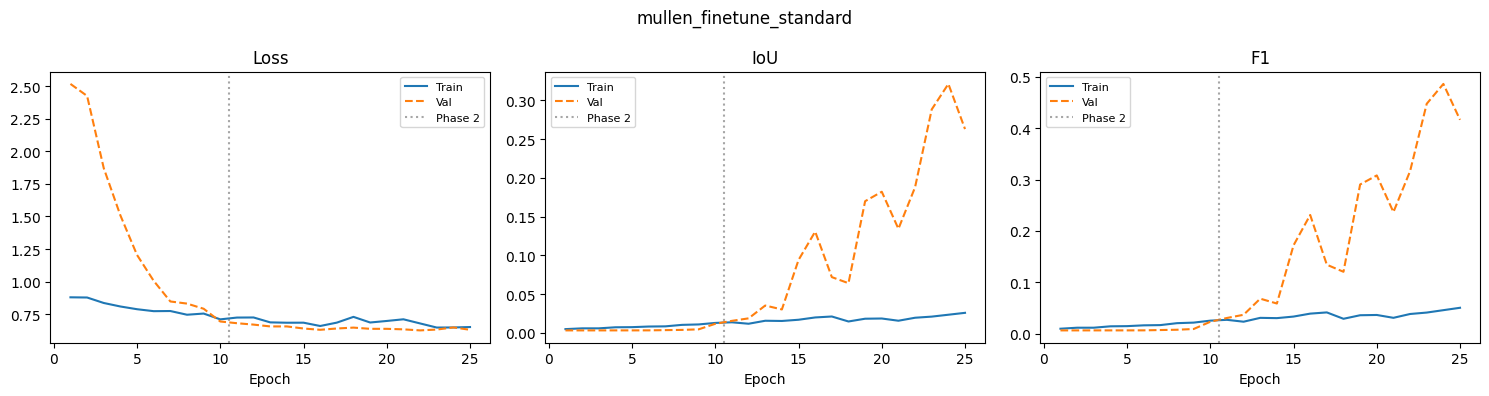

Test:   0%|          | 0/2 [00:00<?, ?it/s]


── mullen_finetune_standard Test Results ──────────────
  loss      : 0.6033
  iou       : 0.1931
  f1        : 0.3236
  precision : 0.1998
  recall    : 0.8521
Logged 'mullen_finetune_standard' to experiment_log.csv


In [26]:
# ── Experiment 2: Fine-tuned with standard augmentation ───────────────────────
results_2 = run_experiment({
    "name":        "mullen_finetune_standard",
    "n_bands":     11,
    "augmentation":"standard",
    "fine_tune":   True,
    "notes":       "Mullen weights → 11-band, gradual unfreeze, standard augmentation"
})


  Experiment : mullen_finetune_aggressive
  Bands      : 11
  Augment    : aggressive
  Fine-tune  : True

Transferring Mullen encoder weights...
  Stem conv: keras (3, 3, 5, 64) → pytorch (64, 11, 3, 3)
  Directly transferred: 1 tensors
  Block weights: transfer by shape-matching in full fine-tune run.
  Run verify_transfer() to confirm encoder is non-trivial.
Encoder feature map stats:
  Level 0: (1, 11, 256, 256)  mean=0.0002  std=1.0000
  Level 1: (1, 64, 128, 128)  mean=0.2587  std=0.6757
  Level 2: (1, 48, 64, 64)  mean=-0.0001  std=0.0018
  Level 3: (1, 80, 32, 32)  mean=-0.0000  std=0.0000
  Level 4: (1, 224, 16, 16)  mean=-0.0000  std=0.0000
  Level 5: (1, 640, 8, 8)  mean=-0.0000  std=0.0000
Water fraction: 0.6%  weights: non-water=0.012, water=1.988

── Phase 1: Frozen encoder ──
  Encoder frozen. Trainable params: 3,308,514
[mullen_finetune_aggressive][phase1] Epoch 001/25 | train loss 0.9719 IoU 0.004 F1 0.009 | val loss 1.4842 IoU 0.003 F1 0.006 | lr 1.00e-04
[mullen_fin

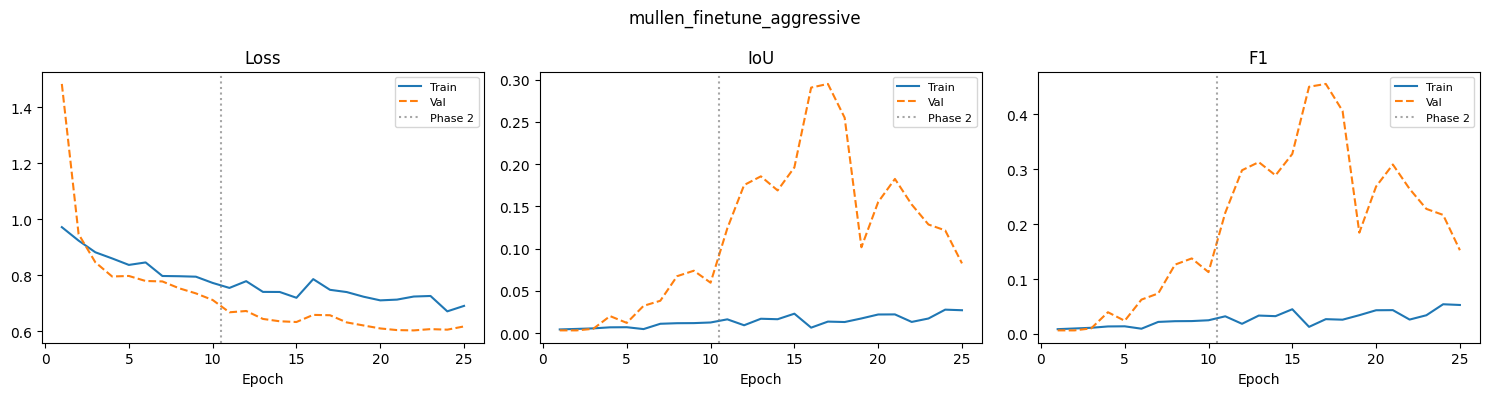

Test:   0%|          | 0/2 [00:00<?, ?it/s]


── mullen_finetune_aggressive Test Results ──────────────
  loss      : 0.5876
  iou       : 0.1352
  f1        : 0.2381
  precision : 0.1388
  recall    : 0.8387
Logged 'mullen_finetune_aggressive' to experiment_log.csv


In [27]:
# ── Experiment 3: Fine-tuned with aggressive augmentation ─────────────────────
results_3 = run_experiment({
    "name":        "mullen_finetune_aggressive",
    "n_bands":     11,
    "augmentation":"aggressive",
    "fine_tune":   True,
    "notes":       "Mullen weights → 11-band, gradual unfreeze, aggressive augmentation"
})

---
## 7. Results Comparison

In [28]:
log_path = EXPERIMENTS_DIR / "experiment_log.csv"
df = pd.read_csv(log_path)
exp_order = ["mullen_unaltered","mullen_finetune_standard","mullen_finetune_aggressive"]
df_show   = df[df["name"].isin(exp_order)].set_index("name").loc[
    [e for e in exp_order if e in df["name"].values]]
display(df_show[["test_iou","test_f1","test_precision","test_recall",
                 "n_bands","augmentation","fine_tune"]].round(4))

,test_iou,test_f1,test_precision,test_recall,n_bands,augmentation,fine_tune
name,,,,,,,
mullen_unaltered,0.0028,0.0057,0.0028,0.9584,5,none,False
mullen_finetune_standard,0.1931,0.3236,0.1998,0.8521,11,standard,True
mullen_finetune_aggressive,0.1352,0.2381,0.1388,0.8387,11,aggressive,True


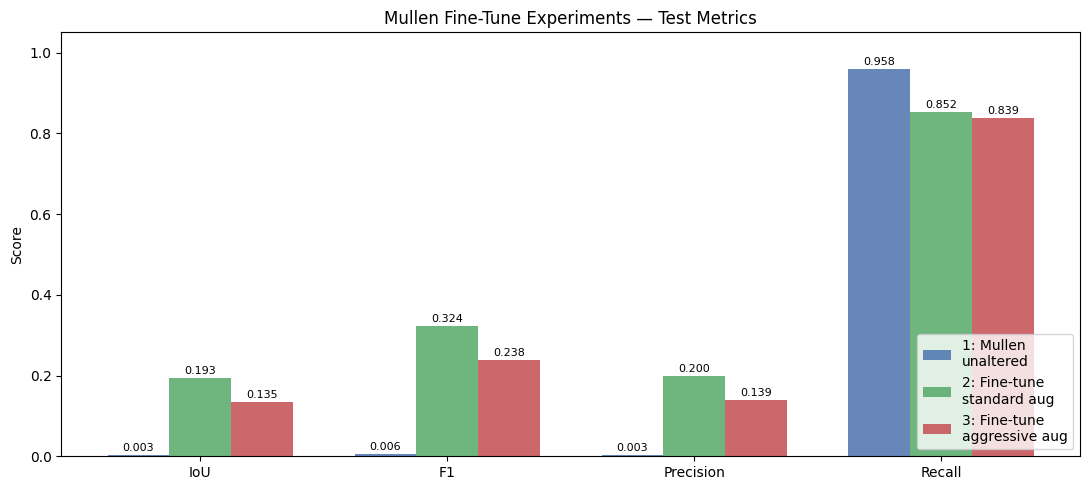

In [29]:
# ── Comparison bar chart ──────────────────────────────────────────────────────
metrics_cols = ["test_iou","test_f1","test_precision","test_recall"]
labels       = ["IoU","F1","Precision","Recall"]
exp_labels   = [
    "1: Mullen\nunaltered",
    "2: Fine-tune\nstandard aug",
    "3: Fine-tune\naggressive aug",
]
colours = ["#4C72B0","#55A868","#C44E52"]
x, width = np.arange(len(metrics_cols)), 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (exp_name, label, colour) in enumerate(zip(exp_order, exp_labels, colours)):
    if exp_name not in df_show.index: continue
    row    = df_show.loc[exp_name]
    values = [row[m] for m in metrics_cols]
    bars   = ax.bar(x + i*width, values, width, label=label,
                    color=colour, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Mullen Fine-Tune Experiments — Test Metrics")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(EXPERIMENTS_DIR / "experiment_comparison.png", dpi=150)
plt.show()

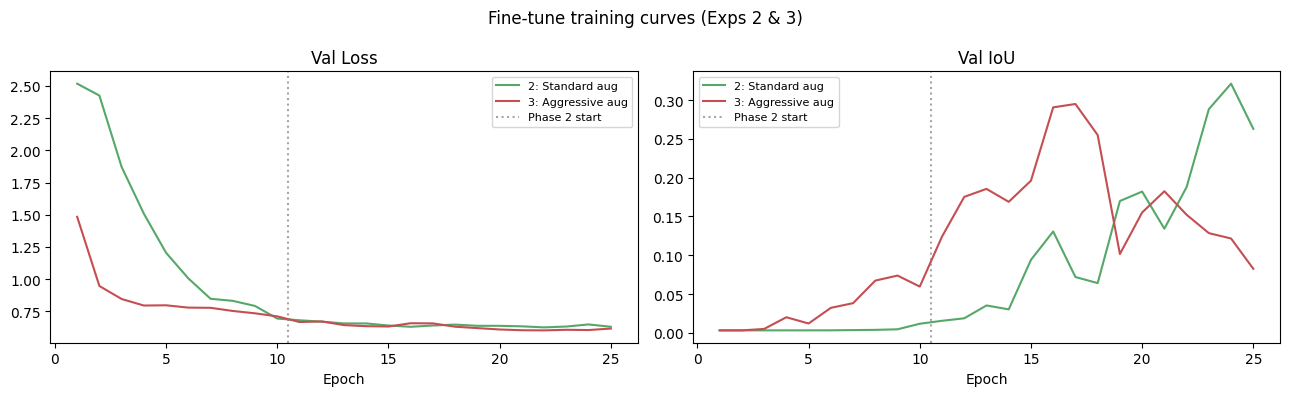

In [30]:
# ── Val IoU overlay — fine-tuned experiments ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for results, label, colour in [
    (results_2, "2: Standard aug",   "#55A868"),
    (results_3, "3: Aggressive aug", "#C44E52"),
]:
    h  = results["history"]
    ep = range(1, len(h["val_loss"]) + 1)
    axes[0].plot(ep, h["val_loss"], label=label, color=colour)
    axes[1].plot(ep, h["val_iou"],  label=label, color=colour)

for ax, title in zip(axes, ["Val Loss","Val IoU"]):
    ax.axvline(x=PHASE1_EPOCHS+0.5, color="grey", linestyle=":",
               alpha=0.7, label="Phase 2 start")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend(fontsize=8)

plt.suptitle("Fine-tune training curves (Exps 2 & 3)", fontsize=12)
plt.tight_layout()
plt.savefig(EXPERIMENTS_DIR / "val_curves_overlay.png", dpi=150)
plt.show()

---
## 8. Inference on All Local Tiles — Mullen Unaltered Model

Runs the original Mullen UNet (Experiment 1, no fine-tuning) on **all** local labeled
scenes — not just the test split — to measure full-dataset transfer performance.
This gives the most complete picture of how well the Alaska model generalises to NC
before any fine-tuning.

Outputs:
- Per-tile and aggregate metrics (IoU, F1, Precision, Recall)
- Grid plot of false colour + classification for every tile
- Results saved to `experiment_log_all_tiles.csv`

In [11]:
FULL_PS_IMAGE  = DRIVE_ROOT / "data" / "local_nc" / "PS" / "20240716_151643_20_24c8_3B_AnalyticMS_SR_8b_reproject_bandmath.tif"  # ← update

prepare_slope_tiles([FULL_PS_IMAGE], tile_gdf, tile_path_col=TILE_PATH_COL)

# see if there's a way to read in the full PS image by tile,
# then run inference by tile using the matching slope tiles
# this would save data storage and maybe time

Aligning slope tiles for 1 PS images...
  20240716_151643_20_24c8_3B_AnalyticMS_SR_8b_reproject_bandmath.tif: 12 tile(s)
    ✓ aligned: 20240716_151643_20_24c8_3B_AnalyticMS_SR_8b_reproject_bandmath.tif
Done.


In [12]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Full PS image for Section 9 inference
FULL_PS_IMAGE  = DRIVE_ROOT / "data" / "local_nc" / "PS" / "20240716_151643_20_24c8_3B_AnalyticMS_SR_8b_reproject_bandmath.tif"  # ← update
FULL_PS_SLOPE  = DRIVE_ROOT / "data" / "local_nc" / "slope" / "20240716_151643_20_24c8_3B_AnalyticMS_SR_8b_reproject_bandmath.tif"  # ← update

# Inset location in the full PS image (pixels) — update to frame a water body of interest
INSET_ROW = 3072     # top-left row of 1024x1024 inset
INSET_COL = 3072     # top-left col of 1024x1024 inset
INSET_SIZE = 1024

# Which best model to use for full-scene inference (Section 9)
# Options: "mullen_unaltered", "mullen_finetune_standard", "mullen_finetune_aggressive"
INFERENCE_EXP = "mullen_unaltered"
INFERENCE_BANDS = 5   # 5 for unaltered, 11 for fine-tuned

INFERENCE_DIR = EXPERIMENTS_DIR / "inference"
INFERENCE_DIR.mkdir(exist_ok=True)

In [13]:
def get_chip_offsets_full(total, chip_size):
    offsets = list(range(0, total - chip_size + 1, chip_size))
    if not offsets or offsets[-1] + chip_size < total:
        offsets.append(max(0, total - chip_size))
    return offsets


def predict_full_scene_mullen(img_path: Path, slope_path: Path,
                               model: smp.Unet, n_bands: int,
                               slope_mean: float, slope_std: float,
                               chip_size: int = 256,
                               device=DEVICE) -> tuple:
    """
    Tile a full scene, run inference, stitch predictions.
    Returns:
        pred     : uint8 (H, W)   — 0=not-water, 1=water, 255=no-data
        prob_map : float32 (H, W) — water probability 0-1, nan=no-data
    No-data identified via slope nodata (-9999).
    """
    model.eval()
    with rasterio.open(img_path) as src:
        H, W = src.height, src.width
    with rasterio.open(slope_path) as src:
        slope_nodata = src.read(1, masked=False).astype(np.float32)
    nodata_mask = slope_nodata == -9999

    prob_map  = np.zeros((H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.uint8)

    with rasterio.open(img_path) as img_src, \
         rasterio.open(slope_path) as slp_src:
        for r in get_chip_offsets_full(H, chip_size):
            for c in get_chip_offsets_full(W, chip_size):
                window = Window(c, r, chip_size, chip_size)

                if n_bands == 5:
                    # Mullen 5-band: B/G/R/NIR from stored indices + slope
                    spec = img_src.read([2,3,4,6], window=window,
                                        out_dtype=np.float32)
                    spec = preprocess_spectral(spec)
                    slp  = slp_src.read(window=window, out_dtype=np.float32)
                    slp  = preprocess_slope(slp, slope_mean, slope_std)
                    chip = np.concatenate([spec, slp], axis=0)  # (5,H,W)
                else:
                    # 11-band reordered
                    spec = img_src.read(window=window, out_dtype=np.float32)
                    spec = reorder_bands(spec)
                    spec = preprocess_spectral(spec)
                    slp  = slp_src.read(window=window, out_dtype=np.float32)
                    slp  = preprocess_slope(slp, slope_mean, slope_std)
                    chip = np.concatenate([spec, slp], axis=0)  # (11,H,W)

                chip = np.nan_to_num(chip, nan=0.0, posinf=3.0, neginf=-3.0)
                tensor = torch.from_numpy(chip).unsqueeze(0).to(device)
                with torch.no_grad():
                    prob = torch.softmax(
                        model(tensor), dim=1)[0, 1].cpu().numpy()
                prob_map[r:r+chip_size, c:c+chip_size] += prob
                count_map[r:r+chip_size, c:c+chip_size] += 1

    avg_prob = prob_map / np.maximum(count_map, 1)
    avg_prob[nodata_mask] = np.nan
    pred = (avg_prob > 0.5).astype(np.uint8)
    pred[nodata_mask] = 255
    return pred, avg_prob


print("Inference utilities defined.")

Inference utilities defined.


In [14]:
# ── Load Mullen unaltered model ───────────────────────────────────────────────
mullen_model_path = EXPERIMENTS_DIR / "mullen_unaltered" / "best_model.pt"
mullen_model = build_model(n_bands=5).to(DEVICE)
mullen_model.load_state_dict(
    torch.load(mullen_model_path, map_location=DEVICE, weights_only=True))
mullen_model.eval()
print("Mullen unaltered model loaded.")

# ── Run inference on all scenes ───────────────────────────────────────────────
# Uses ALL scenes (train + val + test) for a complete dataset-level assessment
iou_metric_all  = torchmetrics.JaccardIndex(task="binary", ignore_index=255).to(DEVICE)
f1_metric_all   = torchmetrics.F1Score(task="binary",      ignore_index=255).to(DEVICE)
prec_metric_all = torchmetrics.Precision(task="binary",    ignore_index=255).to(DEVICE)
rec_metric_all  = torchmetrics.Recall(task="binary",       ignore_index=255).to(DEVICE)

per_tile_results = []
tile_preds       = []   # store for plot
tile_images      = []   # store for plot
tile_masks       = []   # store for plot

for img_path, slope_path, mask_path in scenes:
    print(f"  {img_path.name}...")
    pred, prob_map = predict_full_scene_mullen(
        img_path, slope_path, mullen_model,
        n_bands=5, slope_mean=SLOPE_MEAN, slope_std=SLOPE_STD,
        chip_size=CHIP_SIZE, device=DEVICE
    )

    # Load ground truth mask
    with rasterio.open(mask_path) as src:
        mask_raw = src.read(1).astype(np.uint8)

    # Update aggregate metrics
    pred_t = torch.from_numpy(pred.astype(np.int64)).unsqueeze(0).to(DEVICE)
    mask_t = torch.from_numpy(mask_raw.astype(np.int64)).unsqueeze(0).to(DEVICE)
    iou_metric_all.update(pred_t,  mask_t)
    f1_metric_all.update(pred_t,   mask_t)
    prec_metric_all.update(pred_t, mask_t)
    rec_metric_all.update(pred_t,  mask_t)

    # Per-tile metrics
    iou_t  = torchmetrics.JaccardIndex(task="binary", ignore_index=255).to(DEVICE)
    f1_t   = torchmetrics.F1Score(task="binary",      ignore_index=255).to(DEVICE)
    prec_t = torchmetrics.Precision(task="binary",    ignore_index=255).to(DEVICE)
    rec_t  = torchmetrics.Recall(task="binary",       ignore_index=255).to(DEVICE)
    iou_t.update(pred_t, mask_t);  f1_t.update(pred_t, mask_t)
    prec_t.update(pred_t, mask_t); rec_t.update(pred_t, mask_t)
    valid_px   = (mask_raw != 255).sum()
    water_pct  = (pred[mask_raw != 255] == 1).sum() / max(valid_px, 1) * 100
    per_tile_results.append({
        "scene":     img_path.stem,
        "split":     "train" if scenes.index((img_path, slope_path, mask_path))
                     in train_scene_idx else
                     "val" if scenes.index((img_path, slope_path, mask_path))
                     in val_scene_idx else "test",
        "iou":       round(iou_t.compute().item(),  4),
        "f1":        round(f1_t.compute().item(),   4),
        "precision": round(prec_t.compute().item(), 4),
        "recall":    round(rec_t.compute().item(),  4),
        "water_pct": round(float(water_pct),        2),
    })

    # Store for plot (downsampled to 512px for memory)
    with rasterio.open(img_path) as src:
        fc_bands = src.read([6,4,3]).astype(np.float32)  # NIR-R-G (stored idx 6,4,3 → 1-indexed 6,4,3)
    fc = fc_bands.transpose(1,2,0)
    p2, p98 = np.nanpercentile(fc, (2, 98))
    fc = np.clip((fc - p2)/(p98 - p2 + 1e-6), 0, 1)
    tile_images.append(fc)
    tile_preds.append(pred)
    tile_masks.append(mask_raw)

# ── Aggregate results ─────────────────────────────────────────────────────────
agg = {
    "IoU":       iou_metric_all.compute().item(),
    "F1":        f1_metric_all.compute().item(),
    "Precision": prec_metric_all.compute().item(),
    "Recall":    rec_metric_all.compute().item(),
}
print("\n── Aggregate Metrics — Mullen Unaltered (all tiles) ──")
for k, v in agg.items(): print(f"  {k:10s}: {v:.4f}")

df_tiles = pd.DataFrame(per_tile_results)
display(df_tiles)
df_tiles.to_csv(INFERENCE_DIR / "mullen_unaltered_per_tile.csv", index=False)
print(f"Per-tile results saved.")

Mullen unaltered model loaded.
  tile_10240_6144.tif...
  tile_10240_7168.tif...
  tile_11264_6144.tif...
  tile_11264_7168.tif...
  tile_11264_8192.tif...
  tile_8192_6144.tif...
  tile_8192_7168.tif...
  tile_9216_6144.tif...
  tile_9216_7168.tif...

── Aggregate Metrics — Mullen Unaltered (all tiles) ──
  IoU       : 0.0040
  F1        : 0.0080
  Precision : 0.0040
  Recall    : 0.9611


,scene,split,iou,f1,precision,recall,water_pct
0,tile_10240_6144,train,0.0013,0.0025,0.0013,0.9161,89.41
1,tile_10240_7168,train,0.0055,0.0109,0.0055,0.9736,93.10
2,tile_11264_6144,train,0.0008,0.0016,0.0008,0.9264,89.91
3,tile_11264_7168,test,0.0028,0.0057,0.0028,0.9584,84.46
4,tile_11264_8192,train,0.0015,0.0030,0.0015,0.9296,86.56
5,tile_8192_6144,train,0.0117,0.0231,0.0117,0.9568,81.17
6,tile_8192_7168,val,0.0012,0.0023,0.0012,0.9452,94.52
7,tile_9216_6144,val,0.0056,0.0112,0.0056,0.9724,92.01
8,tile_9216_7168,train,0.0051,0.0102,0.0051,0.9722,92.90


Per-tile results saved.


In [15]:
# ── Grid plot: false colour + mask + prediction for all tiles ─────────────────
n_scenes  = len(scenes)
mask_cmap = mcolors.ListedColormap(["white", "steelblue", "lightgrey"])
col_titles = ["False Colour (NIR-R-G)", "Ground Truth", "Prediction"]

fig, axes = plt.subplots(n_scenes, 3,
                         figsize=(12, 4 * n_scenes),
                         squeeze=False)

# Column headers on first row
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)

for row_i, (fc, mask_raw, pred, res) in enumerate(
        zip(tile_images, tile_masks, tile_preds, per_tile_results)):

    gt_disp   = np.where(mask_raw == 255, 2, mask_raw)
    pred_disp = np.where(pred == 255,     2, pred)

    axes[row_i, 0].imshow(fc)
    axes[row_i, 0].set_ylabel(
        f"{res['scene']}\n[{res['split']}]", fontsize=8, labelpad=6)
    axes[row_i, 0].axis("off")

    axes[row_i, 1].imshow(gt_disp, cmap=mask_cmap, vmin=0, vmax=2,
                          interpolation="nearest")
    axes[row_i, 1].axis("off")

    axes[row_i, 2].imshow(pred_disp, cmap=mask_cmap, vmin=0, vmax=2,
                          interpolation="nearest")
    # Add per-tile IoU to prediction column
    axes[row_i, 2].set_xlabel(
        f"IoU={res['iou']:.3f}  F1={res['f1']:.3f}",
        fontsize=8)
    axes[row_i, 2].axis("off")

legend_elements = [
    Patch(facecolor="white",     edgecolor="grey", label="Not water"),
    Patch(facecolor="steelblue", edgecolor="grey", label="Water"),
    Patch(facecolor="lightgrey", edgecolor="grey", label="No data"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, 0.005))
plt.suptitle(
    f"Mullen Unaltered — All Local Tiles\n"
    f"Aggregate: IoU={agg['IoU']:.3f}  F1={agg['F1']:.3f}  "
    f"Precision={agg['Precision']:.3f}  Recall={agg['Recall']:.3f}",
    fontsize=12, y=1.005
)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(INFERENCE_DIR / "mullen_unaltered_all_tiles.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Tile grid saved.")

Output hidden; open in https://colab.research.google.com to view.

---
## 9. Full PS Scene Inference with Inset

Runs the selected fine-tuned model on a full PlanetScope scene and produces:
- Full-scene false colour and prediction side by side
- A 1024×1024 inset zoomed to an area of interest, with a locator box
  on the full scene showing where the inset is drawn from
- Georeferenced prediction GeoTIFF saved to Drive

In [14]:
# ── Load selected inference model ─────────────────────────────────────────────
inf_model_path = EXPERIMENTS_DIR / INFERENCE_EXP / "best_model.pt"
inf_model = build_model(n_bands=INFERENCE_BANDS).to(DEVICE)
inf_model.load_state_dict(
    torch.load(inf_model_path, map_location=DEVICE, weights_only=True))
inf_model.eval()
print(f"Loaded: {INFERENCE_EXP} ({INFERENCE_BANDS}-band)")

# ── Run full-scene inference ───────────────────────────────────────────────────
print(f"Running inference on {FULL_PS_IMAGE.name}...")
pred_full, prob_full = predict_full_scene_mullen(
    FULL_PS_IMAGE, FULL_PS_SLOPE, inf_model,
    n_bands=INFERENCE_BANDS,
    slope_mean=SLOPE_MEAN, slope_std=SLOPE_STD,
    chip_size=CHIP_SIZE, device=DEVICE
)

# Save georeferenced prediction GeoTIFF
with rasterio.open(FULL_PS_IMAGE) as ref:
    profile = ref.profile.copy()
    H_full, W_full = ref.height, ref.width
profile.update(count=1, dtype="uint8", compress="lzw", nodata=255)
pred_out = INFERENCE_DIR / f"{FULL_PS_IMAGE.stem}_{INFERENCE_EXP}_pred.tif"
with rasterio.open(pred_out, "w", **profile) as dst:
    dst.write(pred_full[np.newaxis, ...])
print(f"Saved: {pred_out.name}")

# Save probability raster (scaled *1000, uint16)
prob_uint16 = np.where(np.isnan(prob_full), 65535,
                       (prob_full * 1000).clip(0, 1000)).astype(np.uint16)
prob_profile = profile.copy()
prob_profile.update(dtype="uint16", nodata=65535)
prob_out = INFERENCE_DIR / f"{FULL_PS_IMAGE.stem}_{INFERENCE_EXP}_prob.tif"
with rasterio.open(prob_out, "w", **prob_profile) as dst:
    dst.write(prob_uint16[np.newaxis, ...])
print(f"Saved: {prob_out.name}")

Loaded: mullen_unaltered (5-band)
Running inference on 20240716_151643_20_24c8_3B_AnalyticMS_SR_8b_reproject_bandmath.tif...
Saved: 20240716_151643_20_24c8_3B_AnalyticMS_SR_8b_reproject_bandmath_mullen_unaltered_pred.tif
Saved: 20240716_151643_20_24c8_3B_AnalyticMS_SR_8b_reproject_bandmath_mullen_unaltered_prob.tif


In [ ]:
# ── Load full false colour and probability maps ───────────────────────────────
with rasterio.open(FULL_PS_IMAGE) as src:
    # NIR-R-G false colour (stored 1-indexed: nir=6, red=4, green=3)
    fc_full = src.read([6, 4, 3]).astype(np.float32).transpose(1, 2, 0)
p2, p98 = np.nanpercentile(fc_full, (2, 98))
fc_full = np.clip((fc_full - p2) / (p98 - p2 + 1e-6), 0, 1)

# ── Inset region ──────────────────────────────────────────────────────────────
r0, c0 = INSET_ROW, INSET_COL
r1 = min(r0 + INSET_SIZE, H_full)
c1 = min(c0 + INSET_SIZE, W_full)

fc_inset   = fc_full[r0:r1, c0:c1]
pred_inset = np.where(pred_full == 255, 2,
                      pred_full)[r0:r1, c0:c1]
prob_inset = prob_full[r0:r1, c0:c1]   # float32, nan = no-data

# ── Probability threshold map ─────────────────────────────────────────────────
# 0 = not water (prob < 0.95)
# 1 = probable water (0.95 <= prob < 0.99) — light blue
# 2 = confident water (prob >= 0.99)       — dark blue
# 3 = no-data (nan)                        — light grey
prob_class = np.full_like(prob_inset, 3, dtype=np.uint8)   # default: no-data
valid      = ~np.isnan(prob_inset)
prob_class[valid & (prob_inset <  0.95)] = 0
prob_class[valid & (prob_inset >= 0.95) & (prob_inset < 0.99)] = 1
prob_class[valid & (prob_inset >= 0.99)] = 2

prob_cmap = mcolors.ListedColormap([
    "white",          # 0: not water
    "#AED6F1",        # 1: probable water  (light blue)
    "#1A5276",        # 2: confident water (dark blue)
    "lightgrey",      # 3: no-data
])
prob_norm = mcolors.BoundaryNorm([0, 1, 2, 3, 4], prob_cmap.N)

# ── Binary mask colourmap ─────────────────────────────────────────────────────
mask_cmap = mcolors.ListedColormap(["white", "steelblue", "lightgrey"])

# ── 3-column inset plot ───────────────────────────────────────────────────────
# Columns: false colour | binary prediction | probability thresholds
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Col 0: False colour
axes[0].imshow(fc_inset)
axes[0].set_title("False Colour (NIR-R-G)", fontsize=11, fontweight="bold")
axes[0].axis("off")

# Col 1: Binary prediction (> 0.5 threshold)
axes[1].imshow(pred_inset, cmap=mask_cmap, vmin=0, vmax=2,
               interpolation="nearest")
water_pct = (pred_inset[pred_inset != 2] == 1).sum() / \
             max((pred_inset != 2).sum(), 1) * 100
axes[1].set_title(f"Binary Prediction (>0.5)\nwater={water_pct:.1f}%",
                  fontsize=11, fontweight="bold")
axes[1].axis("off")

# Col 2: Probability thresholds
axes[2].imshow(prob_class, cmap=prob_cmap, norm=prob_norm,
               interpolation="nearest")
n_prob  = (prob_class == 1).sum()
n_conf  = (prob_class == 2).sum()
n_valid = valid[r0:r1, c0:c1].sum() if valid.shape == prob_full.shape \
          else (~np.isnan(prob_inset)).sum()
axes[2].set_title(
    f"Probability Thresholds\n"
    f"probable (0.95–0.99): {n_prob:,}px  confident (≥0.99): {n_conf:,}px",
    fontsize=11, fontweight="bold")
axes[2].axis("off")

# Legends
binary_legend = [
    Patch(facecolor="white",     edgecolor="grey", label="Not water"),
    Patch(facecolor="steelblue", edgecolor="grey", label="Water (>0.50)"),
    Patch(facecolor="lightgrey", edgecolor="grey", label="No data"),
]
prob_legend = [
    Patch(facecolor="white",    edgecolor="grey", label="Not water (<0.95)"),
    Patch(facecolor="#AED6F1",  edgecolor="grey", label="Probable (0.95–0.99)"),
    Patch(facecolor="#1A5276",  edgecolor="grey", label="Confident (≥0.99)"),
    Patch(facecolor="lightgrey",edgecolor="grey", label="No data"),
]
axes[1].legend(handles=binary_legend, loc="lower right",
               fontsize=7, framealpha=0.85)
axes[2].legend(handles=prob_legend, loc="lower right",
               fontsize=7, framealpha=0.85)

plt.suptitle(
    f"{FULL_PS_IMAGE.stem} — Inset rows {r0}:{r1}, cols {c0}:{c1}\n"
    f"Model: {INFERENCE_EXP}",
    fontsize=12, y=1.02
)
plt.tight_layout()
out_fig = INFERENCE_DIR / f"{FULL_PS_IMAGE.stem}_inset_plot.png"
plt.savefig(out_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"Inset figure saved: {out_fig.name}")